Nombre: Emilio Rico Hernández
Clase: 7
Challenge: Time Series Detective
Fecha: 2026-09-25

# Challenge 7 — Time Series Detective

La dirección afirma: **"Las ventas están creciendo y presentan un patrón semanal."** Reviso si los datos lo respaldan.

Uso `ventas_1.csv` (transacciones de enero a agosto de 2026). Como cada fila es una venta y no un día, primero sumo las ventas de cada día.

Nota: en este entorno no tenía `statsmodels`, así que la ACF la calculo con `autocorr` en un ciclo y la prueba ADF la escribí a mano (regresión con 7 rezagos). En vez de un p-valor, comparo el estadístico con los valores críticos usuales (-3.43 al 1%, -2.86 al 5% y -2.57 al 10%).

## Paso 1 — Preparar la serie

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

df = pd.read_csv("ventas_1.csv")
df["Fecha"] = pd.to_datetime(df["Fecha"])
df = df.sort_values("Fecha").set_index("Fecha")

# cada fila es una venta: sumo las ventas de cada día
serie = df.groupby("Fecha")["Ventas"].sum()
serie.head()

Fecha
2026-01-01     6187.60
2026-01-02    50124.35
2026-01-03    32250.26
2026-01-04    16945.66
2026-01-05    35192.72
Name: Ventas, dtype: float64

## Paso 2 — Auditoría temporal

In [2]:
print("Primera fecha:", serie.index.min().date())
print("Última fecha:", serie.index.max().date())
print("Observaciones:", len(serie))
print("Frecuencia:", pd.infer_freq(serie.index))
print("Valores faltantes:", serie.isna().sum())
print("Huecos:", len(pd.date_range(serie.index.min(), serie.index.max()).difference(serie.index)))
print("Promedio, desv. estándar, mínimo y máximo:", serie.mean().round(0), serie.std().round(0), serie.min().round(0), serie.max().round(0))

Primera fecha: 2026-01-01
Última fecha: 2026-08-10
Observaciones: 222
Frecuencia: D
Valores faltantes: 0
Huecos: 0
Promedio, desv. estándar, mínimo y máximo: 34121.0 24936.0 593.0 113851.0


La serie va del 1 de enero al 10 de agosto de 2026: 222 días, frecuencia diaria, sin valores faltantes ni huecos (hubo ventas todos los días). El promedio es de $34,121 al día, pero la desviación estándar es de $24,936 y el rango va de $593 a $113,851, así que es una serie muy irregular.

## Paso 3 — Visualización de la serie original

Fecha
2026-07-20    113851.0
2026-07-08    110867.0
2026-04-09    103235.0
2026-07-21     99490.0
2026-07-02     97476.0
Name: Ventas, dtype: float64
           Producto    Ventas
Fecha                        
2026-05-09   Laptop  48336.93
2026-06-25   Laptop  46806.57
2026-07-09   Laptop  46288.74
          mean      std
Fecha                  
1      35790.0  21344.0
2      35773.0  23016.0
3      25728.0  18742.0
4      31700.0  25569.0
5      30970.0  24034.0
6      32070.0  26310.0
7      50268.0  30580.0
8      23474.0  16055.0


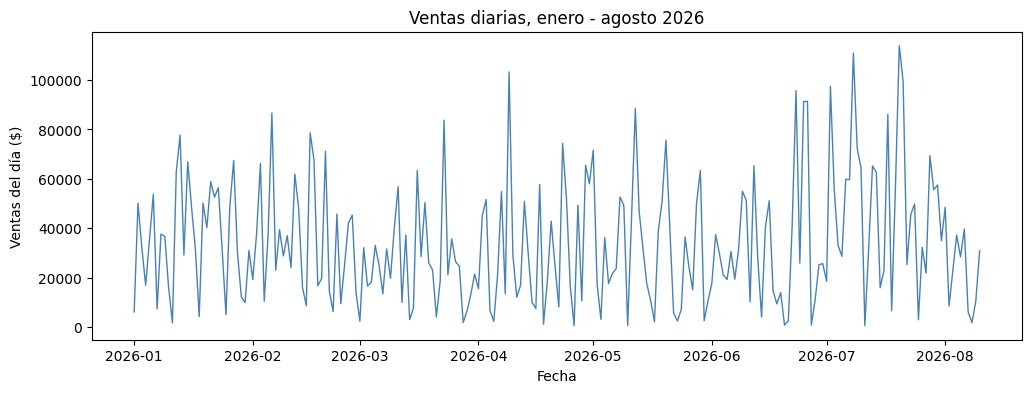

In [3]:
plt.figure(figsize=(12, 4))
plt.plot(serie.index, serie.values, color="steelblue", linewidth=1)
plt.title("Ventas diarias, enero - agosto 2026")
plt.xlabel("Fecha")
plt.ylabel("Ventas del día ($)")
plt.show()

print(serie.nlargest(5).round(0))
print(df.nlargest(3, "Ventas")[["Producto", "Ventas"]])
print(serie.groupby(serie.index.month).agg(["mean", "std"]).round(0))   # variabilidad por mes

Lun    43456.0
Mar    46548.0
Mié    32638.0
Jue    41699.0
Vie    45364.0
Sáb    15812.0
Dom    13673.0
Name: Ventas, dtype: float64


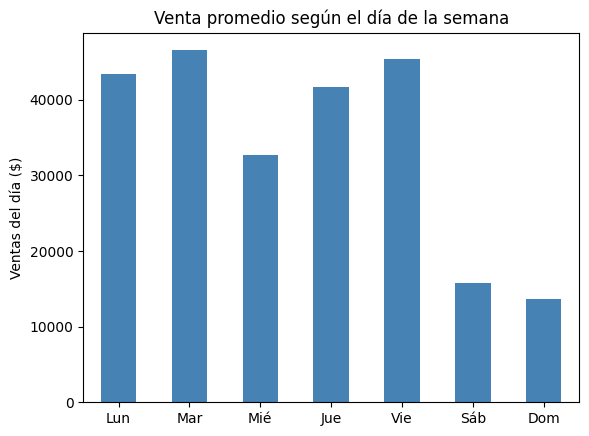

In [4]:
# ¿hay un patrón por día de la semana?
por_dia = serie.groupby(serie.index.dayofweek).mean()
por_dia.index = ["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"]
por_dia.plot(kind="bar", color="steelblue", rot=0, title="Venta promedio según el día de la semana")
plt.ylabel("Ventas del día ($)")
plt.show()
print(por_dia.round(0))

1. **¿Tendencia?** A simple vista no: casi todo el periodo oscila entre $0 y $60 mil, con un tramo más alto en julio. Lo pruebo con una regresión en el Paso 5.
2. **¿Patrón repetitivo?** Sí. Sábado y domingo venden $15,812 y $13,673 en promedio, menos de la mitad que cualquier día entre semana (de $32,638 el miércoles a $46,548 el martes).
3. **¿Picos?** Sí. Los 5 días más altos van de $97,476 a $113,851 y cuatro son de julio. Las ventas individuales más grandes son laptops de $46 a $48 mil, así que los picos parecen venir de días con alguna venta muy cara.
4. **¿Cambia la variabilidad?** Sí: la desviación estándar mensual va de $16,055 (agosto) a $30,580 (julio), y es más alta justo cuando sube el nivel.

## Paso 4 — Resampling

                  sum     mean
Fecha                         
2026-01-01  1109483.0  35790.0
2026-02-01  1001652.0  35773.0
2026-03-01   797569.0  25728.0
2026-04-01   951010.0  31700.0
2026-05-01   960064.0  30970.0
2026-06-01   962108.0  32070.0
2026-07-01  1558301.0  50268.0
2026-08-01   234737.0  23474.0


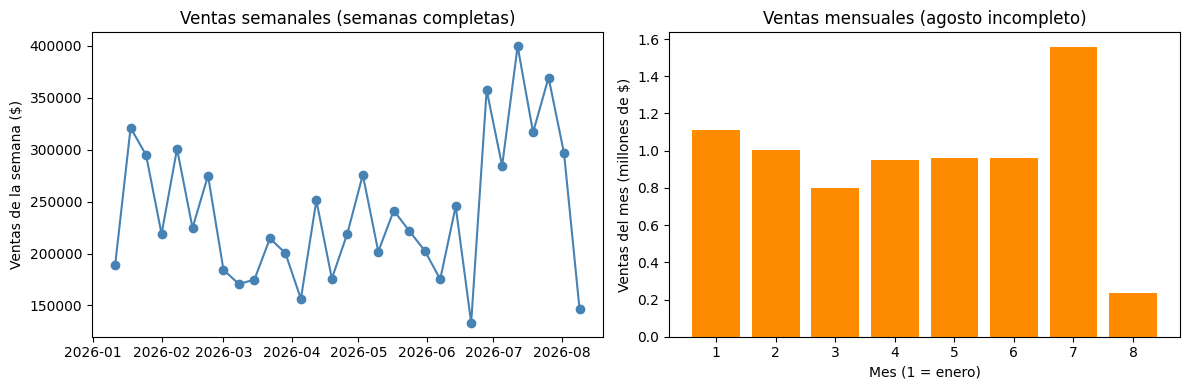

In [5]:
semanal = serie.resample("W").sum().iloc[1:-1]   # quito la primera y la última semana (incompletas)
mensual = serie.resample("MS").agg(["sum", "mean"])

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(semanal.index, semanal.values, marker="o", color="steelblue")
ax[0].set_title("Ventas semanales (semanas completas)")
ax[0].set_ylabel("Ventas de la semana ($)")
ax[1].bar(mensual.index.month, mensual["sum"] / 1e6, color="darkorange")
ax[1].set_title("Ventas mensuales (agosto incompleto)")
ax[1].set_xlabel("Mes (1 = enero)")
ax[1].set_ylabel("Ventas del mes (millones de $)")
plt.tight_layout()
plt.show()
print(mensual.round(0))

Quité la primera y la última semana porque están incompletas. Agosto tiene solo 10 días, por eso su total ($234,737) parece un desplome; su promedio por día ($23,474) es más justo, aunque 4 de esos días son fin de semana.

La serie **semanal** suaviza el patrón por día de la semana y deja ver el nivel: las semanas de julio son las más altas de toda la serie (hasta casi $400 mil). La **mensual** es todavía más suave, pero son solo 7 meses completos: julio suma $1,558,301 contra $797,569 a $1,109,483 en los otros meses completos. Solo con los totales parecería crecimiento, pero el promedio por día muestra un salto en julio ($50,268 contra $25,728 a $35,790 en enero-junio), no una subida gradual.

## Paso 5 — Medias móviles

Desv. estándar: diaria 24936 | MA7 9646 | MA30 6541
MA30 mínimo: 25511 2026-03-22 | máximo: 52373 2026-07-21
Pendiente: 29.3 $/día, p = 0.263, R² = 0.006


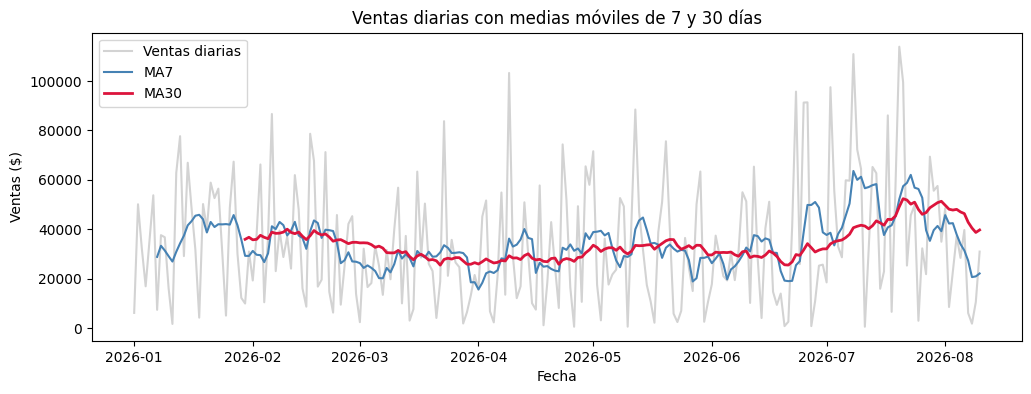

In [6]:
ma7 = serie.rolling(7).mean()
ma30 = serie.rolling(30).mean()

plt.figure(figsize=(12, 4))
plt.plot(serie.index, serie.values, color="lightgray", label="Ventas diarias")
plt.plot(ma7.index, ma7.values, color="steelblue", label="MA7")
plt.plot(ma30.index, ma30.values, color="crimson", linewidth=2, label="MA30")
plt.title("Ventas diarias con medias móviles de 7 y 30 días")
plt.xlabel("Fecha")
plt.ylabel("Ventas ($)")
plt.legend()
plt.show()

print("Desv. estándar: diaria", round(serie.std()), "| MA7", round(ma7.std()), "| MA30", round(ma30.std()))
print("MA30 mínimo:", round(ma30.min()), ma30.idxmin().date(), "| máximo:", round(ma30.max()), ma30.idxmax().date())

# ¿hay tendencia? regresión lineal de las ventas contra el número de día
reg = stats.linregress(np.arange(len(serie)), serie.values)
print(f"Pendiente: {reg.slope:.1f} $/día, p = {reg.pvalue:.3f}, R² = {reg.rvalue ** 2:.3f}")

La MA7 baja la desviación estándar de $24,936 (diaria) a $9,646, porque cada ventana incluye un sábado y un domingo y casi desaparece el ciclo semanal. La MA30 es aún más suave ($6,541) y muestra el nivel de fondo: empieza en ~$36 mil, sube a ~$40 mil en febrero, baja a un mínimo de $25,511 el 22 de marzo, se mueve entre ~$26 y ~$35 mil hasta junio, llega a un máximo de $52,373 el 21 de julio y regresa a ~$40 mil en agosto. La MA7 reacciona rápido; la MA30 es lenta pero enseña mejor la tendencia.

**Tendencia:** la regresión da una pendiente de +$29 al día, pero con p = 0.263 y R² = 0.006 no es distinta de cero. No hay crecimiento sostenido, solo el pico de julio.

## Paso 6 — Diferenciación

Original: media 34121 | desv. estándar 24936
Diferenciada: media 112 | desv. estándar 32640


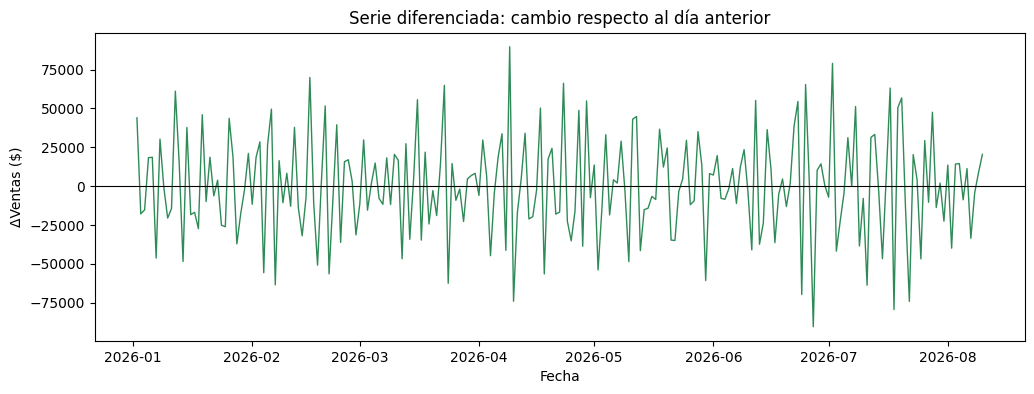

In [7]:
dif = serie.diff().dropna()      # ΔY_t = Y_t - Y_(t-1)

plt.figure(figsize=(12, 4))
plt.plot(dif.index, dif.values, color="seagreen", linewidth=1)
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Serie diferenciada: cambio respecto al día anterior")
plt.xlabel("Fecha")
plt.ylabel("ΔVentas ($)")
plt.show()

print("Original: media", round(serie.mean()), "| desv. estándar", round(serie.std()))
print("Diferenciada: media", round(dif.mean()), "| desv. estándar", round(dif.std()))

La serie diferenciada oscila alrededor de cero (media de $112) y ya no tiene nivel, pero su desviación estándar sube de $24,936 a $32,640. Al restar el día anterior se suma el ruido de dos días, señal de que la serie no tenía una tendencia que quitar. Además se siguen viendo los saltos del ciclo semanal.

## Paso 7 — Lags

In [8]:
lags = pd.DataFrame({"ventas": serie})
for k in [1, 7, 14, 30]:
    lags[f"lag{k}"] = serie.shift(k)
lags.iloc[30:35]

,ventas,lag1,lag7,lag14,lag30
Fecha,,,,,
2026-01-31,31001.66,9976.03,31238.24,31660.02,6187.60
2026-02-01,19298.22,31001.66,5094.17,4266.05,50124.35
2026-02-02,37796.86,19298.22,48706.91,50209.84,32250.26
2026-02-03,66220.36,37796.86,67354.04,40291.08,16945.66
2026-02-04,10487.02,66220.36,30178.00,58867.87,35192.72


## Paso 8 — Autocorrelación

autocorr lag 1: 0.145
autocorr lag 7: 0.309
autocorr lag 14: 0.23
autocorr lag 30: -0.205
Rezagos fuera de la banda: [1, 5, 7, 14, 19, 21, 23, 28, 30, 33, 35, 37, 40]
Autocorr lag 1 de la serie diferenciada: -0.345


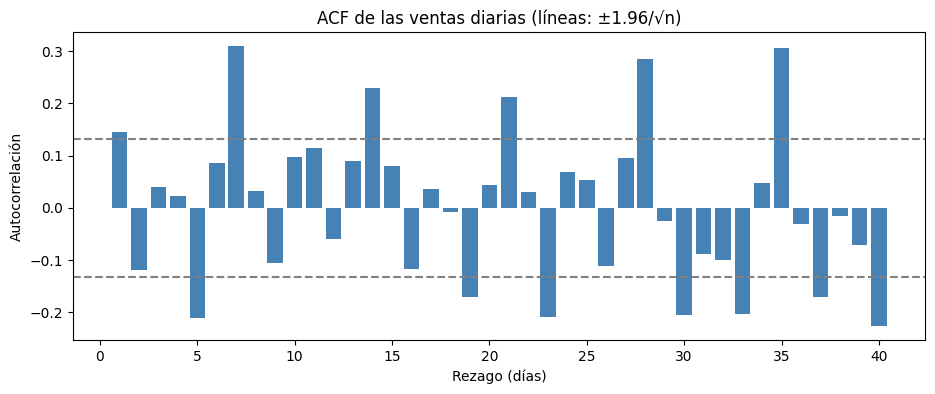

In [9]:
for k in [1, 7, 14, 30]:
    print(f"autocorr lag {k}:", round(serie.autocorr(lag=k), 3))

# ACF: la autocorrelación de cada rezago del 1 al 40, con su banda de ±1.96/√n
acf = [serie.autocorr(k) for k in range(1, 41)]
banda = 1.96 / np.sqrt(len(serie))

plt.figure(figsize=(11, 4))
plt.bar(range(1, 41), acf, color="steelblue")
plt.axhline(banda, color="gray", linestyle="--")
plt.axhline(-banda, color="gray", linestyle="--")
plt.title("ACF de las ventas diarias (líneas: ±1.96/√n)")
plt.xlabel("Rezago (días)")
plt.ylabel("Autocorrelación")
plt.show()

print("Rezagos fuera de la banda:", [k for k in range(1, 41) if abs(acf[k - 1]) > banda])
print("Autocorr lag 1 de la serie diferenciada:", round(dif.autocorr(lag=1), 3))

Las autocorrelaciones son: lag 1 = 0.145, lag 7 = 0.309, lag 14 = 0.23 y lag 30 = -0.205. El lag 7 es el más alto: las ventas de hoy se parecen más a las del mismo día de la semana pasada que a las de ayer.

En la ACF sobresalen de la banda los múltiplos de 7 (7, 14, 21, 28 y 35, todos positivos), que es la firma de una estacionalidad semanal. También salen rezagos negativos (5, 19, 23, 30, 33, 37 y 40): todos caen a 2 días de un múltiplo de 7, donde se compara un día hábil con uno de fin de semana.

En la serie diferenciada el lag 1 vale -0.345, una autocorrelación negativa típica de una serie sobrediferenciada.

## Paso 9 — Estacionariedad (prueba ADF)

H₀: la serie tiene raíz unitaria (no es estacionaria). Se rechaza si el estadístico es menor que el valor crítico.

In [10]:
def adf(y, rezagos=7):
    # regresión: Δy_t = c + g*y_(t-1) + b1*Δy_(t-1) + ... ; el estadístico ADF es g / error estándar de g
    d = np.diff(y)
    Y = d[rezagos:]
    X = [np.ones(len(Y)), y[rezagos:-1]]
    for i in range(1, rezagos + 1):
        X.append(d[rezagos - i:-i])
    X = np.column_stack(X)
    b = np.linalg.lstsq(X, Y, rcond=None)[0]
    e = Y - X @ b
    varianza = e @ e / (len(Y) - X.shape[1])
    return b[1] / np.sqrt(varianza * np.linalg.inv(X.T @ X)[1, 1])

print("Valores críticos: 1% = -3.43 | 5% = -2.86 | 10% = -2.57")
for nombre, s in [("original", serie), ("diferenciada", dif)]:
    t = adf(s.values)
    print(f"ADF {nombre}: {t:.2f} -> ¿menor que -2.86? {t < -2.86}")
print("ADF de la original con 14 rezagos:", round(adf(serie.values, 14), 2))   # ¿depende del número de rezagos?

Valores críticos: 1% = -3.43 | 5% = -2.86 | 10% = -2.57
ADF original: -4.04 -> ¿menor que -2.86? True
ADF diferenciada: -8.59 -> ¿menor que -2.86? True
ADF de la original con 14 rezagos: -2.01


Con 7 rezagos (una semana), el estadístico ADF de la serie original es -4.04, menor que el crítico al 1% (-3.43): rechazo H₀, no hay raíz unitaria y la serie se considera estacionaria. La diferenciada da -8.59, también estacionaria, pero eso era de esperarse y no aporta.

Ojo: el resultado depende del número de rezagos. Con 14 en vez de 7 la original da -2.01, que ya no rechaza H₀ ni al 10%. Elegí 7 porque el ciclo es semanal, pero como el resultado cambia, no tomo la conclusión de "estacionaria" como algo firme. Además la ADF solo busca raíz unitaria: no detecta el patrón semanal ni el salto de julio, y estacionaria no significa "sin patrón".

## Preguntas de reflexión

1. **¿Las ventas realmente tienen tendencia?** No de forma demostrable: la pendiente es de +$29 al día pero con p = 0.263 y R² = 0.006, y la MA30 baja hasta marzo y solo sube en julio. Hay un salto en julio, no una tendencia sostenida.
2. **¿Existe evidencia de patrón semanal?** Sí. Sábado y domingo venden mucho menos que los demás días, el lag 7 tiene la mayor autocorrelación (0.309) y la ACF tiene picos en 7, 14, 21, 28 y 35.
3. **¿Qué lag tiene mayor relación con el presente?** El lag 7 (0.309), luego el 14 (0.23). El lag 1, el día anterior, es débil (0.145).
4. **¿La serie original parece estacionaria?** Según la ADF con 7 rezagos sí (-4.04 contra -3.43 al 1%), pero con 14 rezagos da -2.01 y no rechaza, así que la conclusión es frágil. Además, a la vista tiene ciclo semanal y más variabilidad en julio, que la prueba no revisa.
5. **¿La diferenciación cambia el resultado?** El veredicto no (la diferenciada da -8.59), pero la serie empeora: su desviación estándar sube de $24,936 a $32,640 y el lag 1 pasa a -0.345. No hacía falta diferenciar.
6. **¿La afirmación de la dirección está respaldada?** A medias: el patrón semanal sí, el crecimiento no.

## Conclusión

La dirección dice que las ventas crecen y tienen un patrón semanal, y los datos respaldan solo la segunda parte. El patrón semanal es claro: sábado y domingo venden menos de la mitad que cualquier día entre semana, el lag 7 tiene la mayor autocorrelación (0.309) y la ACF marca picos en todos los múltiplos de 7. En cambio no encontré crecimiento: la pendiente lineal no es significativa (p = 0.263), la MA30 baja hasta marzo y se estabiliza, y lo que parece crecimiento es un salto en julio (promedio de $50,268 al día contra $25,728 a $35,790 en enero-junio) que no se sostiene en agosto, aunque agosto solo tiene 10 días. La ADF con 7 rezagos dice que la serie es estacionaria (con 14 ya no lo dice, así que no es una conclusión firme), y diferenciarla solo agrega ruido. Con solo siete meses de datos no puedo saber si julio es un evento aislado o una temporada, así que no le confirmaría a la dirección que las ventas crecen hasta tener más historia.